
# Ensembl Liftoff vs. Ssal_v3.1 native annotation

This notebook analyses the gene-level comparison between:

* `ICSASG_v2` Ensembl genes lifted to the Ssal_v3.1 assembly (via Liftoff).
* The native Ensembl annotation on Ssal_v3.1.

The input is the streamed comparison output stored at
`experiments/comparison_runs/ens_lift_vs_native.tsv`, generated by
`within_assembly_compare.py`.


In [1]:

import os
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATA_PATH = Path('..') / 'experiments' / 'comparison_runs' / 'ens_lift_vs_native.tsv'
MPL_CACHE = Path('..') / 'experiments' / 'comparison_runs' / 'mpl-cache'
MPL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(MPL_CACHE)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


In [2]:

# Load TSV and expand the stats column into numeric fields
columns = ['feature', 'annA', 'geneA', 'txA', 'annB', 'geneB', 'txB', 'stats']
df = pd.read_csv(DATA_PATH, sep='	', names=columns, header=0)
genes = df[df['feature'] == 'gene'].copy()

def stats_to_dict(stat_string: str) -> dict:
    items = {}
    for chunk in str(stat_string).split(';'):
        if not chunk or '=' not in chunk:
            continue
        key, value = chunk.split('=', 1)
        items[key] = value
    return items

stats_df = genes['stats'].apply(stats_to_dict).apply(pd.Series)
merged = pd.concat([genes.reset_index(drop=True), stats_df], axis=1)
merged['best_jaccard_exon'] = pd.to_numeric(merged['best_jaccard_exon'], errors='coerce')
merged['best_jaccard_cds_phase'] = pd.to_numeric(merged['best_jaccard_cds_phase'], errors='coerce')
merged['stableA'] = merged['geneA'].str.split(':').str[-1]
merged['stableB'] = merged['geneB'].str.split(':').str[-1]
merged['stable_same'] = merged['stableA'] == merged['stableB']

merged.head()


,feature,annA,geneA,txA,annB,geneB,txB,stats,best_coding,best_jaccard_cds_phase,...,partner_countA,partner_countB,strand_match,note_split_or_merge_A,antisense_overlap,note_antisense_conflict,note_split_or_merge_B,stableA,stableB,stable_same
0,gene,ens_lift,gene:ENSSSAG00000000063,.,ens_native,gene:ENSSSAG00000000063,.,best_coding=Yellow;best_jaccard_cds_phase=0.61...,Yellow,0.6155,...,1,1,1,NaN,NaN,NaN,NaN,ENSSSAG00000000063,ENSSSAG00000000063,True
1,gene,ens_lift,gene:ENSSSAG00000000049,.,ens_native,gene:ENSSSAG00000000049,.,best_coding=Yellow;best_jaccard_cds_phase=0.89...,Yellow,0.8955,...,1,1,1,NaN,NaN,NaN,NaN,ENSSSAG00000000049,ENSSSAG00000000049,True
2,gene,ens_lift,gene:ENSSSAG00000000050,.,ens_native,gene:ENSSSAG00000101513,.,best_coding=Green;best_jaccard_cds_phase=1.000...,Green,1.0000,...,1,1,1,NaN,NaN,NaN,NaN,ENSSSAG00000000050,ENSSSAG00000101513,False
3,gene,ens_lift,gene:ENSSSAG00000000051,.,ens_native,gene:ENSSSAG00000000051,.,best_coding=Yellow;best_jaccard_cds_phase=0.65...,Yellow,0.6547,...,1,1,1,NaN,NaN,NaN,NaN,ENSSSAG00000000051,ENSSSAG00000000051,True
4,gene,ens_lift,gene:ENSSSAG00000000052,.,ens_native,gene:ENSSSAG00000000052,.,best_coding=Green;best_jaccard_cds_phase=1.000...,Green,1.0000,...,1,1,1,NaN,NaN,NaN,NaN,ENSSSAG00000000052,ENSSSAG00000000052,True



## Classification counts


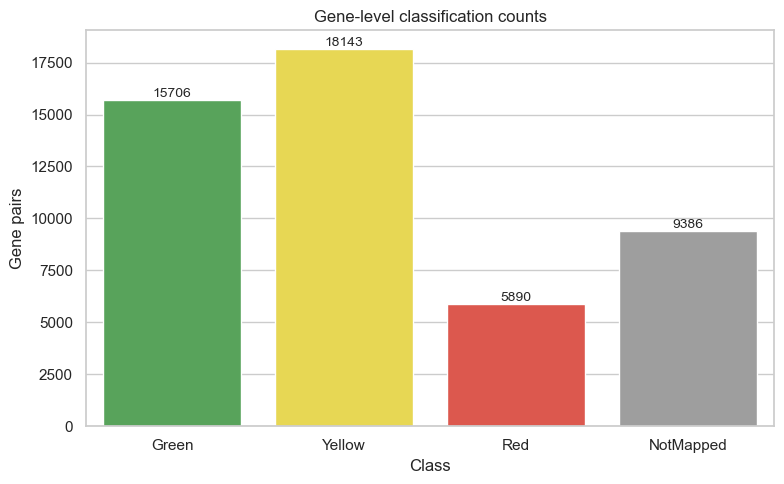

In [ ]:
class_order = ['Green', 'Yellow', 'Red', 'NotMapped']
class_counts = merged['class'].value_counts().reindex(class_order).fillna(0).astype(int)
display(class_counts.to_frame('gene_pairs'))

class_palette = {
    'Green': '#4CAF50',
    'Yellow': '#FFEB3B',
    'Red': '#F44336',
    'NotMapped': '#9E9E9E'
}

ax = sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette=class_palette, legend=False)
ax.set_title('Gene-level classification counts')
ax.set_xlabel('Class')
ax.set_ylabel('Gene pairs')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10)
plt.tight_layout()
plt.show()



## Stable Ensembl IDs


stable_same,False,True
class,,
Green,3767,11939
NotMapped,9332,54
Red,4793,1097
Yellow,6631,11512


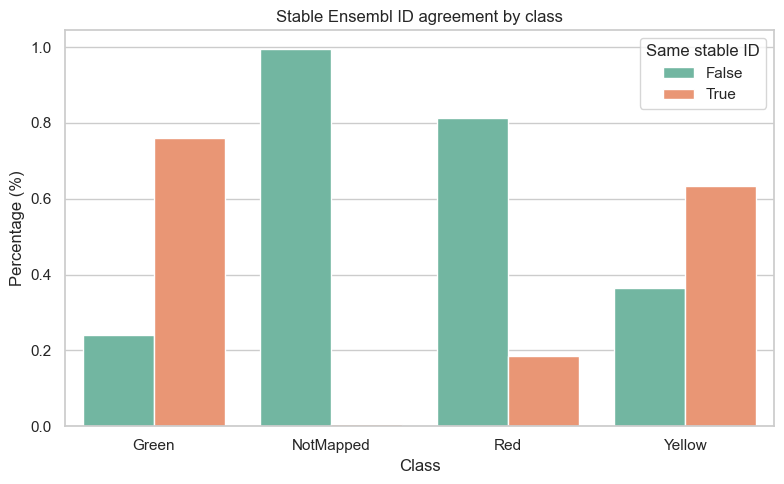

In [8]:

stable_summary = merged.groupby(['class', 'stable_same']).size().unstack(fill_value=0)
display(stable_summary)

stable_pct = (stable_summary.T / stable_summary.sum(axis=1)).T.reset_index().melt(
    id_vars='class', var_name='stable_same', value_name='percentage'
)
ax = sns.barplot(data=stable_pct, x='class', y='percentage', hue='stable_same', palette='Set2')
ax.set_title('Stable Ensembl ID agreement by class')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Class')
ax.legend(title='Same stable ID')
plt.tight_layout()
plt.show()



## Jaccard distributions


/var/folders/y9/jpq6s85931v3sp079xzt1qv40000gn/T/ipykernel_5046/1671258460.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  jaccard_counts = merged.groupby(['jaccard_bin', 'class']).size().unstack(fill_value=0).reindex(columns=class_order)


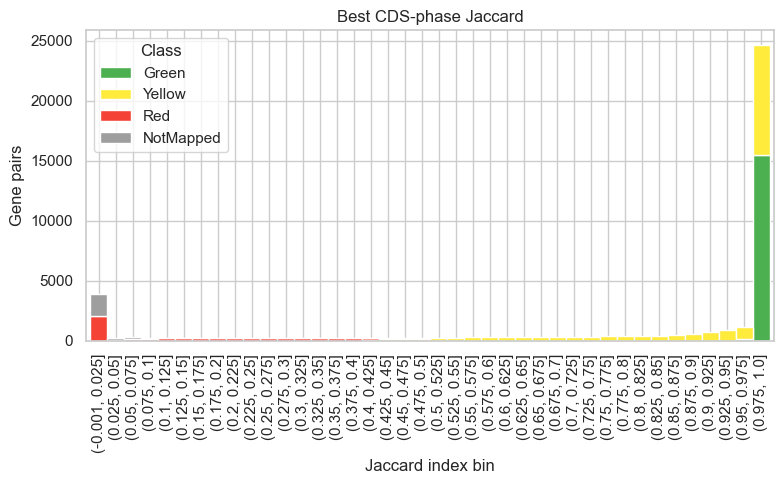

/var/folders/y9/jpq6s85931v3sp079xzt1qv40000gn/T/ipykernel_5046/1671258460.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  jaccard_counts = merged.groupby(['jaccard_bin', 'class']).size().unstack(fill_value=0).reindex(columns=class_order)


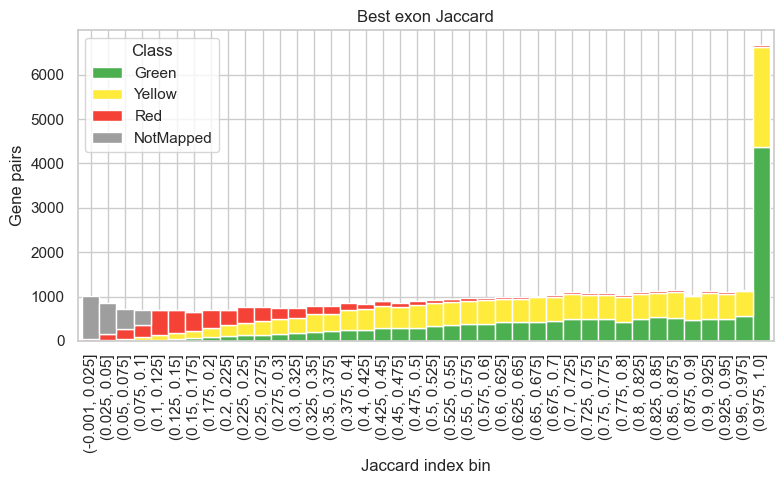

In [13]:
import numpy as np


for column, title in [
    ('best_jaccard_cds_phase', 'Best CDS-phase Jaccard'),
    ('best_jaccard_exon', 'Best exon Jaccard'),
]:
    # Bin the Jaccard values
    bins = np.linspace(0, 1, 41)
    merged['jaccard_bin'] = pd.cut(merged[column], bins=bins, include_lowest=True)
    # Count by class and bin
    jaccard_counts = merged.groupby(['jaccard_bin', 'class']).size().unstack(fill_value=0).reindex(columns=class_order)
    # Plot stacked bar
    ax = jaccard_counts.plot(
        kind='bar',
        stacked=True,
        color=[class_palette[c] for c in class_order],
        width=1,
        legend=True
    )
    ax.set_title(title)
    ax.set_xlabel('Jaccard index bin')
    ax.set_ylabel('Gene pairs')
    ax.legend(title='Class')
    plt.tight_layout()
    plt.show()
    merged.drop(columns='jaccard_bin', inplace=True)



## Notes

* Most lifted genes map cleanly (Green/Yellow), while `NotMapped` cases
  either fail quality thresholds or represent antisense overlaps.
* Stable Ensembl IDs align for roughly half the dataset; mismatches are
  concentrated in weaker classes.
* Histograms highlight that CDS Jaccard scores are bimodal with peaks
  near complete agreement and moderate divergence.
